<h1><center> EKSPLORASI DERET WAKTU </center></h1>
KELOMPOK 7 :

1. Nur Jannah Tuasikal (M0501251002)
2. Rismawati Saputri (A2502251012)
3. Syifa Ul Qalbi YMD (M0501251026)
4. Estyaningsi Purnama (M0501251058)

<center>
_____________________________________________________________________________________________________________________________
</center>


In [6]:
#PACKAAGE
#package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 75.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=23cc877405c4b6ebabf6f77693c8a2cfd133cd4a46efed8b4128e429219d4789
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

initiated datasets repo at: /root/.pydataset/


## **1. Import Data**



In [8]:
link = "https://raw.githubusercontent.com/syifaymd/Pratikum-Analisis-Deret-Waktu/main/Konsumsi%20listrik%20listrik"
nao = pd.read_csv(link, sep=';')

nao.head()

#melihat struktur data
nao.dtypes

,0
periode,object
listrik,float64


**a. Pemasukan dan Pemeriksaan Awal Data**

In [9]:
# melihat 5 data pertama
nao.head()

,periode,listrik
0,Jan-13,16961.49236
1,Feb-13,17571.04985
2,Mar-13,17362.44422
3,Apr-13,18227.87292
4,May-13,18273.59476


In [10]:
#melihat 5 data terakhir
nao.tail()

,periode,listrik
126,Jul-23,24645.45565
127,Aug-23,25126.35282
128,Sep-23,25433.76944
129,Oct-23,26633.69422
130,Nov-23,26755.41154


In [11]:
#cek missing values
nao.isnull().sum()

,0
periode,0
listrik,0


Berdasarkan hasil tahapan awal pemeriksaan data dapat ditunjukan bahawa pada data konsumsi listrik tidak terdapat nilai amatan yang kosong atau **NA**

#**2. Pembentukan Indeks Waktu**

In [12]:
import numpy as np

In [13]:
print(nao.columns)

Index(['periode', 'listrik'], dtype='object')


In [14]:
print(nao['periode'].head())

0    Jan-13
1    Feb-13
2    Mar-13
3    Apr-13
4    May-13
Name: periode, dtype: object


In [15]:
# Mengubah format string seperti 'Jan-13' menjadi datetime (misal: format '%b-%y' untuk Jan-13)
nao['date'] = pd.to_datetime(nao['periode'], format='%b-%y', errors='coerce')

# Ekstrak tahun dan bulan
nao['year'] = nao['date'].dt.year
nao['month'] = nao['date'].dt.month

# Cek hasilnya
display(nao.head())

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


In [16]:
nao.head()

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


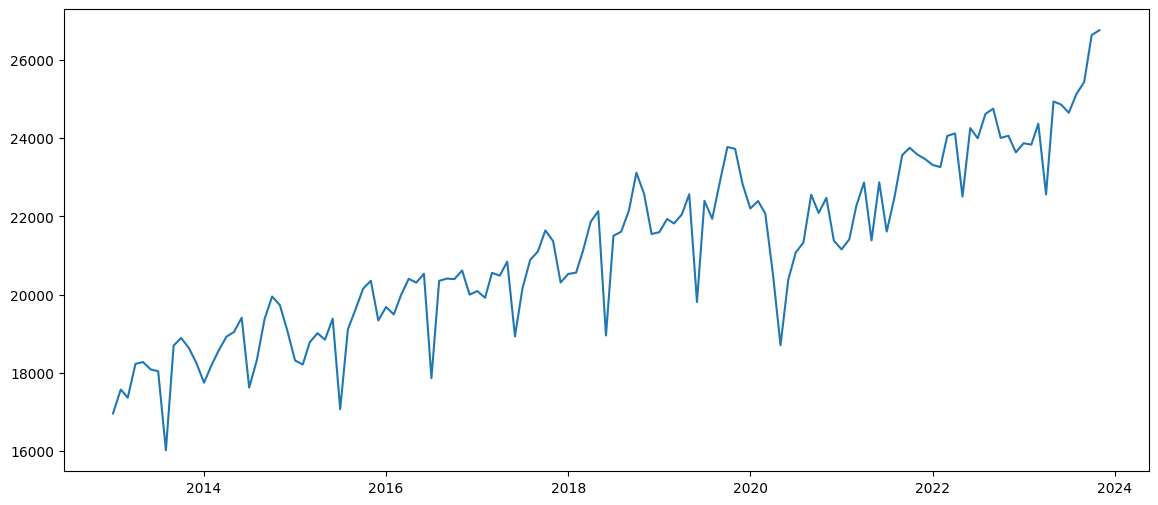

In [17]:
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['listrik']); plt.show()

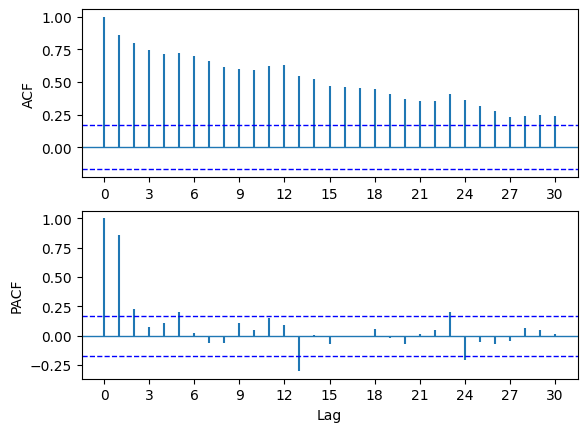

In [18]:
# membuat plot ACF dan PACF contoh dari data nao
acf_pacf_fig(nao['listrik'], both=True, lag=30)

Berdasarkan plot ACF dan PACF contoh yang diperoleh apakah deret stasioner? Mengapa?
<br>
Berdasarkan hasil yang ditunjukan oleh PLOT ACF da PACF diatas diketahui deret tersebut tidak stasioner, dapat dijelaskan sebagai berikut :
*   Nilai koefisien autokorelasi (ACF) mengalami penurunan (decay) sangat lambat dan bertahap dari lag ke lag (tidak langsung turun mendekati nol dengan cepat). Pola penurunan yang lambat seperti ini merupakan indikator utama bahwa deret waktu tidak stasioner dalam rata-rata (biasanya karena mengandung unsur tren atau unit root).
*   Karakteristik Stasioner:
Pada deret waktu yang stasioner, nilai ACF biasanya akan turun drastis dan mendekati nol (berada di dalam batas garis biru putus-putus) setelah beberapa lag awal.
</br>

Selain berdasarkan plot deret, kestasioneran suatu deret dapat diperiksa menggunakan uji statistik, salah satunya adalah uji ADF. Hipotesis yang digunakan dalam uji ADF adalah

$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [19]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(nao['listrik'])[1]

0.9805463853858516

Bagaimana interpretasi hasil uji tersebut? Apakah interpretasi hasil uji sama dengan interpretasi dari plot deret maupun plot ACF?
<p>
<br>
Karena nilai $p$-value ($0.9805$) jauh lebih besar dari taraf nyata $0.05$, maka kita gagal menolak $H_0$. Artinya, data deret waktu tersebut mengandung unit root, yang berarti data tidak stasioner.</br>
<br> Keterkaitan :

*   Pada plot ACF, penurunan nilai koefisien yang sangat lambat mengindikasikan adanya unsur tren/non-stasioneritas.
*   Pada uji ADF, nilai $p$-value yang tinggi ($> 0.05$) memperkuat bukti statistik secara matematis bahwa hipotesis nol (data tidak stasioner) tidak dapat ditolak.
</br>
</p>

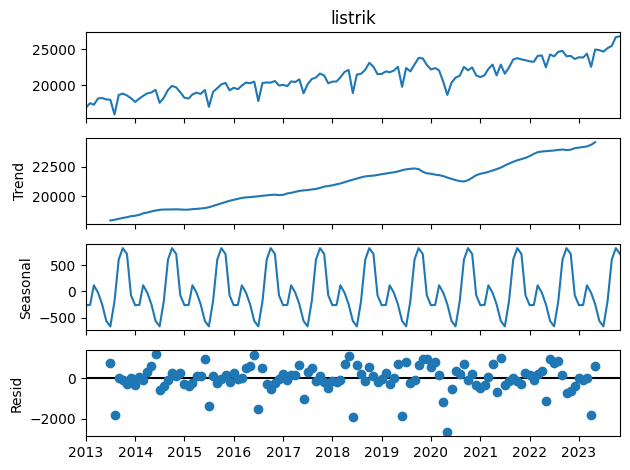

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose
nao2=nao.set_index('date')
result = seasonal_decompose(nao2['listrik'], model='additive')
result.plot()
plt.show()

**Jika dilihat dari hasil dekomposisi tersebut apa interpretasi Anda? Bagaimana keterkaitan hasil dekomposisi dengan interpretasi Anda dari plot ACF dan uji ADF?**

*   Komponen Trend (Tren): Menunjukkan adanya peningkatan (kecenderungan naik) secara konsisten dari tahun 2013 hingga 2023. Adanya tren naik ini membuktikan bahwa rata-rata data berubah seiring waktu.

*   Komponen Seasonal (Musiman): Terlihat adanya pola berulang yang sangat teratur dan konstan setiap tahunnya (pola musiman yang kuat).



**Jika dilihat berdasarkan plot deret apakah deret sudah stasioner dalam ragam?**
<br> Belum tentu / Perlu diperiksa lebih lanjut, namun jika dilihat secara visual dari plot deret utama (paling atas) atau plot residu:</br>



Terdapat dua kestasioneran dalam deret waktu, yaitu kestasioneran dalam nilaitengah dan dalam ragam. Uji ADF hanya digunakan untuk menguji kestasioneran dalam nilaitengah, sementara untuk mengetahui kestasioneran deret dalam ragam dapat dicek melalui uji Boxcox. Jika nilai $\lambda=1$ atau angka 1 masuk dalam interval kepercayaan $\lambda$, maka dapat dikatakan bahwa deret sudah stasioner dalam ragam.

Dalam melakukan transformasi boxcox, perlu diperhatikan bahwa nilai deret harus positif semua. Jika ada nilai deret yang negatif ataupun nol maka deret harus ditransformasi agar nilainya menjadi positif.

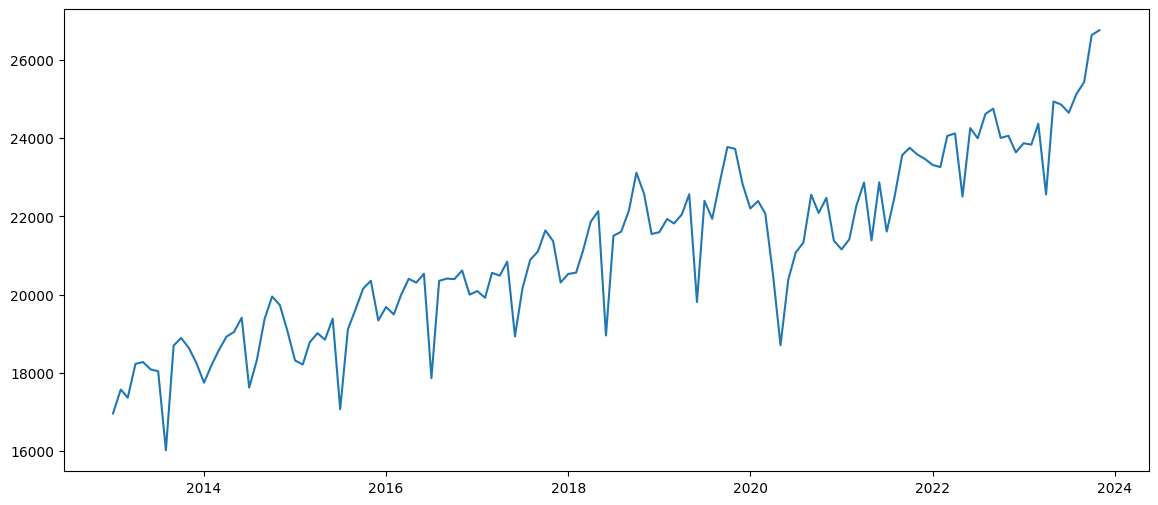

In [21]:
# Plot data baru
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['listrik']); plt.show()

**Berdasarkan plot diatas dapat dijelaskan sebagai berikut :**
<br>
**1. Trend (Tren)**
 *   Pola: Terlihat jelas adanya tren naik (upward trend) dari tahun ke tahun (dari sekitar tahun 2013 hingga mendekati 2024).
*   Makna: Konsumsi atau permintaan listrik mengalami peningkatan jangka panjang seiring berjalannya waktu.

**2. Seasonal / Pola Musiman**

*   Pola: Terdapat fluktuasi atau pola berulang yang cukup konsisten (naik-turun tajam) pada periode waktu tertentu dalam setahun.
*   Makna: Data ini memiliki pola musiman (seasonality), di mana ada bulan-bulan tertentu yang selalu mengalami lonjakan atau penurunan konsumsi secara berulang.

**3. Stasioneritas (Stationarity)**
*   Pola: Karena adanya tren naik yang kuat dari waktu ke waktu, rata-rata (mean) dari data ini tidak konstan.
*   Makna: Secara visual, data deret waktu ini tidak stasioner dalam rata-rata maupun ragam. Oleh karena itu, jika ingin digunakan untuk pemodelan seperti ARIMA, data ini biasanya memerlukan proses differencing (pembedaan) terlebih dahulu agar menjadi stasioner.

**4. Outlier / Anomali**
*   Pola: Terdapat beberapa titik anjlok (drop) yang sangat tajam dan drastis ke bawah pada waktu-waktu tertentu (misalnya beberapa penurunan tajam yang terjadi secara mendadak).
*   Makna: Titik-titik ini menunjukkan adanya pencilan (outlier) atau kejadian khusus yang menyebabkan penurunan konsumsi listrik secara drastis dalam periode singkat sebelum akhirnya naik kembali normal.

In [22]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(nao['listrik'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.22658243494715655
interval kepercayaan lambda: (-1.3047625013508621, 1.7647730226285725)


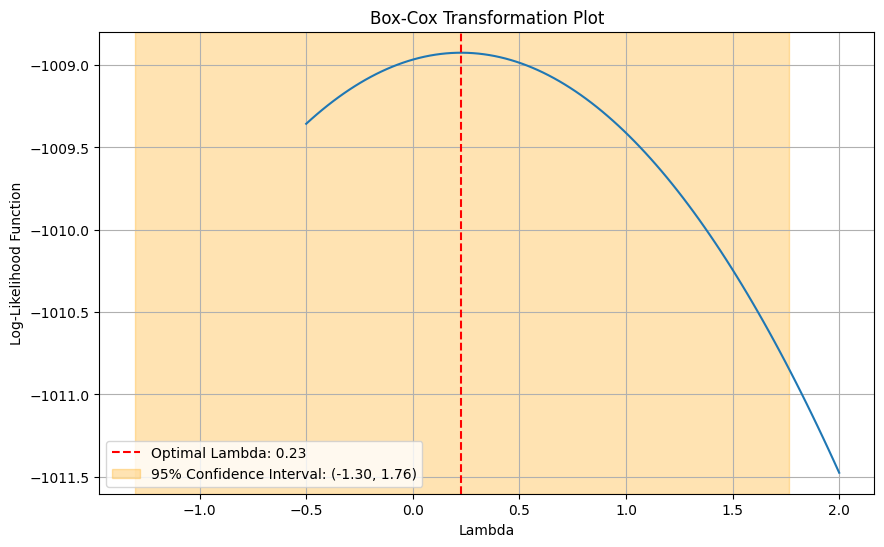

In [23]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, nao['listrik']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

**Bagaimana interpretasi Anda dari nilai lambda yang diperoleh?**
<br>
Berdasarkan plot transformasi Box-Cox, diperoleh nilai $\lambda$ (lambda) optimal sebesar 0.23 dengan selang kepercayaan 95% berada pada rentang -1.30 hingga 1.76. Nilai optimal 0.23 dapat digunakan sebagai acuan parameter transformasi jika ragam data konsumsi listrik perlu distabilkan. Namun, karena nilai 1 (yang merepresentasikan data asli tanpa transformasi) masih berada di dalam rentang selang kepercayaan 95%, secara statistik Anda juga tetap memiliki opsi untuk tidak melakukan transformasi pada data tersebut.</br>

In [24]:
#agregasi data sebagai nilai rata-rata bulanan
naos=nao.groupby(['year','month'])['listrik'].mean()

In [25]:
type(naos)

pandas.core.series.Series

In [26]:
timeindex=pd.date_range('1950-01', periods=len(naos),freq='M')

In [27]:
naos.index=timeindex

In [28]:
naos.head()

,listrik
1950-01-31,16961.49236
1950-02-28,17571.04985
1950-03-31,17362.44422
1950-04-30,18227.87292
1950-05-31,18273.59476


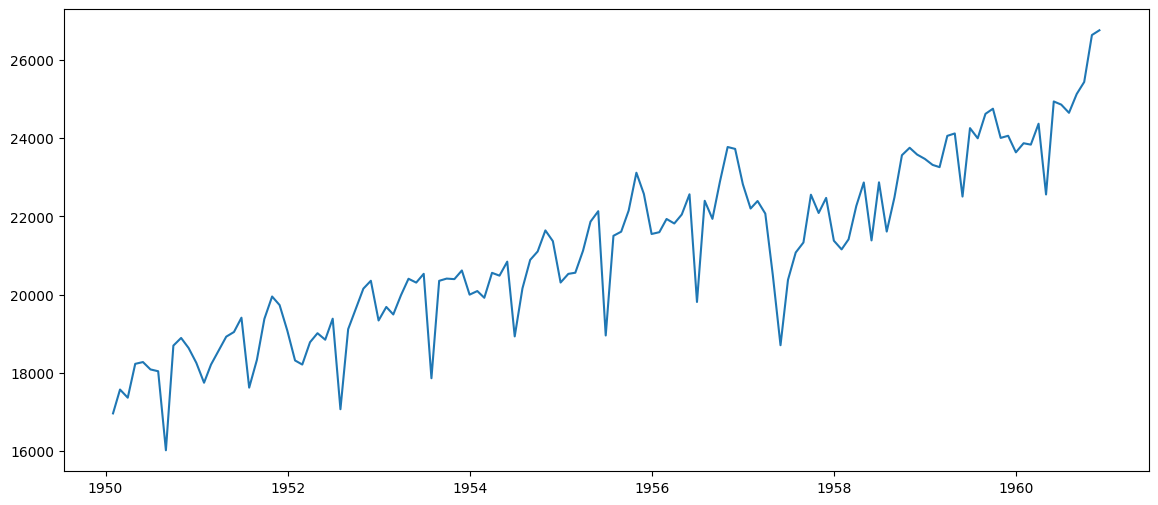

In [29]:
#plot deret waktu
plt.figure(figsize=(14,6))
plt.plot(naos); plt.show()

**Apa perbedaan yang dapat Anda temukan setelah data dilakukan agregasi bulanan?**
<br>
Perbedaan utama yang dapat ditemukan pada plot setelah dilakukan agregasi bulanan (atau perubahan skala waktu pada sumbu-X) adalah tampilan rentang waktu pada sumbu horizontal (sumbu-X) menjadi berbasis tahun kalender yang sebenarnya (rentang dari tahun 1950 hingga setelah 1960), menggantikan indeks angka atau format sebelumnya. Selain itu, pergerakan tren naik dan pola musiman dari data konsumsi listrik tersebut kini terlihat teretensi dan terpetakan secara kronologis per bulan dari tahun 1950 sampai 1961 dengan lebih jelas dan terstruktur.</br>


In [30]:
#ringkasan statistika deret
naos.describe()

,listrik
count,131.000000
mean,21125.928160
std,2228.896835
min,16018.315190
25%,19380.268750
50%,21100.668060
75%,22567.001445
max,26755.411540


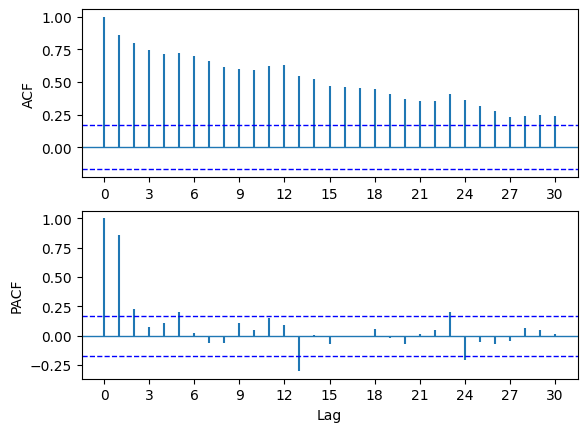

In [31]:
#plot acf dan pacf contoh
acf_pacf_fig(naos, both=True, lag=30); plt.show()

**Bagaimana interpretasi Anda dari plot ACF dan PACF tersebut?**
<br>
Berdasarkan plot ACF dan PACF tersebut, data konsumsi listrik menunjukkan indikasi tidak stasioner karena nilai koefisien pada plot ACF meluruh secara sangat lambat (tails off slowly) seiring bertambahnya lag, sementara plot PACF terpotong tajam setelah lag awal. Pola peluruhan lambat pada ACF ini mengonfirmasi adanya unsur tren yang kuat pada data, sehingga deret waktu tersebut belum memenuhi asumsi stasioneritas dalam rata-rata dan memerlukan proses differencing ($d=1$) sebelum dapat dilanjutkan ke tahap pemodelan ARIMA.</br>

Alat lain yang dapat digunakan untuk memeriksa kestasioneran deret adalah uji Akar-Satuan.

Uji akar satuan yang pertama adalah uji akar-satuan Dickey Fuller (ADF test). Hipotesis yang digunakan dalam uji ADF adalah

$H_0:$ menyatakan deret tidak stasioner

$H_1:$ menyatakan deret stasioner.

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
adfuller(naos, autolag='AIC')[1]

0.9805463853858516

Karena p-value yang diperoleh kurang dari 0.05, dalam hal ini kita tolak $H_0$ sehingga kita yakin bahwa deret tersebut stasioner.

Uji akar-satuan yang lain adalah Kwiatkowski-Phillips-Schmidt-Shin (KPSS). Hipotesis dalam uji KPSS adalah

$H_0:$ deret stasioner

$H_1:$ deret tidak stasioner

In [34]:
sm.tsa.stattools.kpss(naos, regression="c", nlags=50)[1]

np.float64(0.06484673376745415)

Karena p-value yang diperoleh lebih besar dari 0.05, dalam hal ini kita tidak tolak $H_0$ sehingga kita katakan bahwa deret tersebut stasioner.

Menguraikan deret waktu menjadi komponen-komponen penyusunnya terkadang juga membantu dalam proses eksplorasi deret. Secara umum suatu deret waktu terdiri atas 2 komponen, yaitu komponen sistematik dan non-sistematik.

Komponen sistematik adalah komponen yang bersifat konsisten dan berulang dalam deret. Komponen ini dapat dimodelkan. Komponen sistematik dari deret waktu terdiri dari komponen kecenderungan (trend) dan musiman (seasonality).

Sementara komponen non-sistematik adalah komponen acak dalam deret waktu yang tidak dapat dimodelkan secara langsung.

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

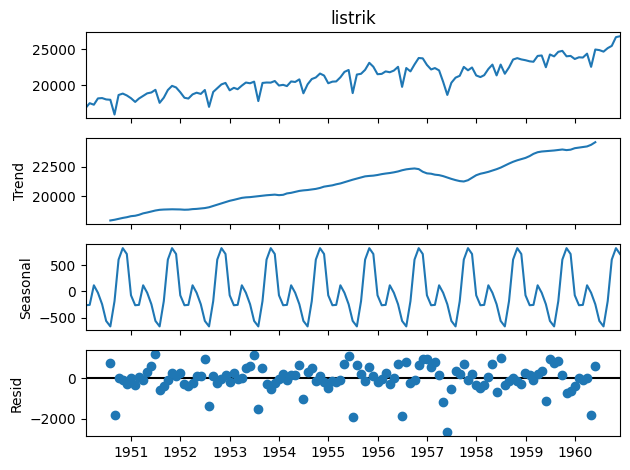

In [36]:
result = seasonal_decompose(naos, model='additive')
result.plot()
plt.show()

In [37]:
naos_positif = naos - naos.min() + 1

In [38]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(naos_positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.7336510709301103
interval kepercayaan lambda: (0.5271753788466396, 0.9890208974235343)


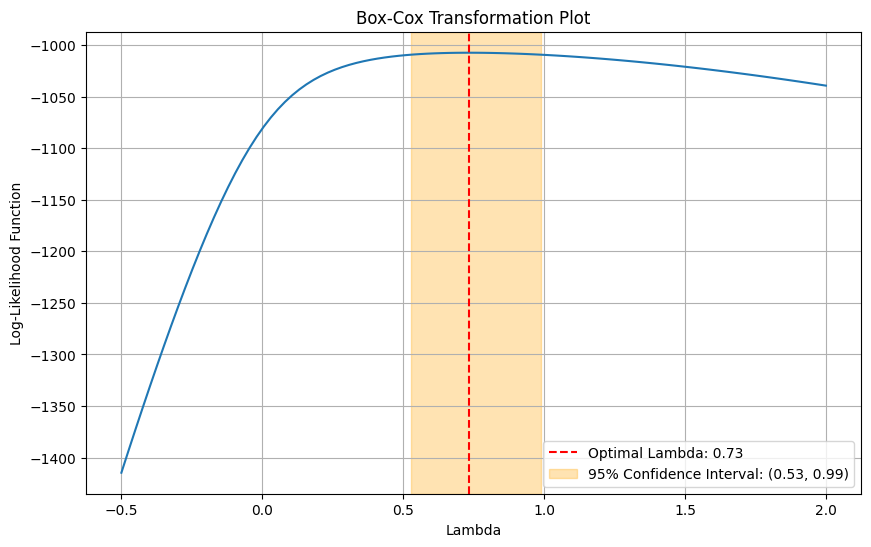

In [39]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, naos_positif) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

### Transformasi Boxcox

Transformasi Box-Cox atau transformasi pangkat digunakan untuk transformasi deret yang **tidak stasioner dalam ragam**. Transformasi Box-Cox didefinisikan sebagai berikut:

$g(x)=\frac{x^\lambda-1}{\lambda}\;\;\; untuk \lambda\ne 0$

$g(x)=\log x \;\;\; untuk \lambda=0$

Perhatikan jika 𝜆 = 1/2 maka menghasilkan transformasi akar kuadrat (jenis transformasi untuk nilai $\lambda$ yang lain dapat dilihat dalam Notodiputro et al 2025).

Transformasi pangkat hanya bisa diaplikasikan terhadap **data yang bernilai positif**. Jika terdapat nilai negatif atau nol, suatu konstanta positif dapat ditambahkan terhadap semua nilai data untuk memperoleh nilai data yang positif sebelum dilakukan transformasi pangkat.

Sebelumnya, hasil eksplorasi pada deret produksi listrik diperoleh nilai $\lambda$ optimum sebesar $0.47 \approx 0.5$, sehingga dapat digunakan transformasi akar kuadrat.